# Delivery Route Optimization
### ADA Capstone Project — E-Commerce Logistics

This notebook integrates multiple algorithmic paradigms:
- **Recurrence** for route cost estimation
- **Greedy + DP** for parcel selection and time-window scheduling
- **Dijkstra + MST** for graph-based route building
- **TSP (Brute-force & Held-Karp DP)** for optimal delivery routing
- **Profiling & Visualization** for performance analysis

---
## Task 1 & 2 — Environment Setup & Input Modeling

In [33]:
# ── Imports ──────────────────────────────────────────────────────────────────
import itertools
import heapq
import time
import math
import sys
import random

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

try:
    from memory_profiler import memory_usage
    MEMORY_PROFILER_AVAILABLE = True
except ImportError:
    MEMORY_PROFILER_AVAILABLE = False
    print("memory_profiler not installed — memory measurements will be skipped.")
    print("Install with: pip install memory_profiler")

print("All imports successful.")

All imports successful.


In [35]:
# ── Input Modeling ────────────────────────────────────────────────────────────
# Locations: 0 = Warehouse, 1-7 = Customer delivery stops
LOCATION_NAMES = {
    0: "Warehouse",
    1: "Customer A",
    2: "Customer B",
    3: "Customer C",
    4: "Customer D",
    5: "Customer E",
    6: "Customer F",
    7: "Customer G",
}

# Distance matrix (symmetric, in km)
# INF means no direct road between locations
INF = float('inf')
DIST_MATRIX = [
    #  0    1    2    3    4    5    6    7
    [  0,  10,  15,  20,  25,  30,  35,  40],  # 0 Warehouse
    [ 10,   0,   8,  12,  18,  22,  28,  35],  # 1 Customer A
    [ 15,   8,   0,   6,  14,  20,  25,  30],  # 2 Customer B
    [ 20,  12,   6,   0,   9,  15,  20,  27],  # 3 Customer C
    [ 25,  18,  14,   9,   0,   7,  13,  22],  # 4 Customer D
    [ 30,  22,  20,  15,   7,   0,   8,  18],  # 5 Customer E
    [ 35,  28,  25,  20,  13,   8,   0,  10],  # 6 Customer F
    [ 40,  35,  30,  27,  22,  18,  10,   0],  # 7 Customer G
]

NUM_LOCATIONS = len(DIST_MATRIX)

# Parcel metadata: (parcel_id, value ₹, weight kg, time_window_start hr, time_window_end hr)
PARCELS = [
    {"id": "P1", "location": 1, "value": 500,  "weight": 3.0, "tw_start": 9,  "tw_end": 12},
    {"id": "P2", "location": 2, "value": 300,  "weight": 5.0, "tw_start": 10, "tw_end": 14},
    {"id": "P3", "location": 3, "value": 800,  "weight": 2.0, "tw_start": 9,  "tw_end": 11},
    {"id": "P4", "location": 4, "value": 200,  "weight": 7.0, "tw_start": 13, "tw_end": 17},
    {"id": "P5", "location": 5, "value": 650,  "weight": 4.5, "tw_start": 11, "tw_end": 15},
    {"id": "P6", "location": 6, "value": 420,  "weight": 3.5, "tw_start": 14, "tw_end": 18},
    {"id": "P7", "location": 7, "value": 900,  "weight": 6.0, "tw_start": 9,  "tw_end": 13},
]

# Vehicle constraint
VEHICLE_CAPACITY = 15.0  # kg
VEHICLE_SPEED    = 40    # km/h
DEPARTURE_TIME   = 9.0   # 9:00 AM

print(f"Locations : {NUM_LOCATIONS}")
print(f"Parcels   : {len(PARCELS)}")
print(f"Vehicle capacity: {VEHICLE_CAPACITY} kg")

Locations : 8
Parcels   : 7
Vehicle capacity: 15.0 kg


---
## Task 3 — Recurrence-Based Route Cost Function

In [4]:
# ── Recursive Route Cost ──────────────────────────────────────────────────────
# Computes the total cost of visiting all nodes and returning to warehouse.
# Recurrence:
#   cost(current, visited) = 0                              if all visited
#   cost(current, visited) = min over unvisited u of
#                            dist[current][u] + cost(u, visited ∪ {u})
# This is a top-down recursive formulation (without memoisation) — exponential.

def recursive_route_cost(current: int, visited: set, locations: list[int]) -> tuple[float, list]:
    """
    Recursively compute minimum cost route visiting all unvisited locations.

    Parameters
    ----------
    current   : current location index
    visited   : set of already-visited indices
    locations : list of all delivery location indices (excluding warehouse=0)

    Returns
    -------
    (min_cost, best_path)
    """
    unvisited = [loc for loc in locations if loc not in visited]

    # Base case — all locations visited; return to warehouse
    if not unvisited:
        return DIST_MATRIX[current][0], [0]  # return to warehouse

    best_cost = INF
    best_path = []

    # Recursive case — try each unvisited next stop
    for next_loc in unvisited:
        travel = DIST_MATRIX[current][next_loc]
        sub_cost, sub_path = recursive_route_cost(next_loc, visited | {next_loc}, locations)
        total = travel + sub_cost
        if total < best_cost:
            best_cost = total
            best_path = [next_loc] + sub_path

    return best_cost, best_path


# Demo on first 5 delivery locations (recurrence is exponential — keep small)
demo_locations = [1, 2, 3, 4, 5]
start_time = time.perf_counter()
cost, path = recursive_route_cost(0, set(), demo_locations)
elapsed = time.perf_counter() - start_time

full_path = [0] + path
named_path = " → ".join(LOCATION_NAMES[n] for n in full_path)

print("Recurrence-Based Route Cost")
print("=" * 45)
print(f"Delivery locations : {[LOCATION_NAMES[l] for l in demo_locations]}")
print(f"Optimal path       : {named_path}")
print(f"Total distance     : {cost} km")
print(f"Time elapsed       : {elapsed*1000:.2f} ms")

Recurrence-Based Route Cost
Delivery locations : ['Customer A', 'Customer B', 'Customer C', 'Customer D', 'Customer E']
Optimal path       : Warehouse → Customer A → Customer E → Customer D → Customer C → Customer B → Warehouse
Total distance     : 69 km
Time elapsed       : 0.72 ms


---
## Task 4 — Greedy + DP for Delivery Planning

In [37]:
# ── Greedy Parcel Selection (Value-to-Weight Ratio) ───────────────────────────
def greedy_parcel_selection(parcels: list[dict], capacity: float) -> list[dict]:
    # Sort by value-to-weight ratio (descending)
    sorted_parcels = sorted(parcels, key=lambda p: p["value"] / p["weight"], reverse=True)

    selected  = []
    total_w   = 0.0
    total_val = 0.0

    for parcel in sorted_parcels:
        if total_w + parcel["weight"] <= capacity:
            selected.append(parcel)
            total_w   += parcel["weight"]
            total_val += parcel["value"]

    return selected, total_w, total_val


selected_greedy, load_greedy, profit_greedy = greedy_parcel_selection(PARCELS, VEHICLE_CAPACITY)

print("Greedy Parcel Selection")
print("=" * 45)
print(f"{'Parcel':<8} {'Value':>7} {'Weight':>8} {'Ratio':>8}")
print("-" * 38)
for p in selected_greedy:
    ratio = p['value'] / p['weight']
    print(f"{p['id']:<8} {p['value']:>7} {p['weight']:>8.1f} {ratio:>8.1f}")
print("-" * 38)
print(f"{'TOTAL':<8} {profit_greedy:>7} {load_greedy:>8.1f}")
print(f"\nCapacity used: {load_greedy}/{VEHICLE_CAPACITY} kg")
print(f"Total profit : ₹{profit_greedy}")

Greedy Parcel Selection
Parcel     Value   Weight    Ratio
--------------------------------------
P3           800      2.0    400.0
P1           500      3.0    166.7
P7           900      6.0    150.0
P6           420      3.5    120.0
--------------------------------------
TOTAL     2620.0     14.5

Capacity used: 14.5/15.0 kg
Total profit : ₹2620.0


In [7]:
# ── DP Time-Window Validation ─────────────────────────────────────────────────
# We simulate the vehicle travelling from warehouse at DEPARTURE_TIME.
# For each greedy-selected parcel (sorted by tw_start), we check whether
# the vehicle can arrive within the delivery window.
#
# DP state: dp[i] = earliest time we can leave location i having delivered
#           parcel i in sorted order.

def dp_time_window_check(
    selected_parcels: list[dict],
    dist_matrix: list[list[float]],
    speed: float,
    depart_time: float
) -> list[dict]:
    """
    Use DP to compute feasible delivery order respecting time windows.

    Returns a list of parcels that can be delivered with arrival and
    departure times, marking infeasible ones.
    """
    # Sort selected parcels by time-window start
    sorted_p = sorted(selected_parcels, key=lambda p: p["tw_start"])

    results  = []
    cur_time = depart_time
    cur_loc  = 0  # Warehouse

    for parcel in sorted_p:
        dest     = parcel["location"]
        travel_t = dist_matrix[cur_loc][dest] / speed  # hours
        arrive   = cur_time + travel_t

        # DP: if we arrive early, wait until window opens
        actual_deliver = max(arrive, parcel["tw_start"])
        feasible       = actual_deliver <= parcel["tw_end"]

        results.append({
            **parcel,
            "arrive_time"  : round(arrive, 2),
            "deliver_time" : round(actual_deliver, 2),
            "feasible"     : feasible,
        })

        # Move to this location after delivery (add 10 min service time)
        cur_time = actual_deliver + (10 / 60)
        cur_loc  = dest

    return results


dp_results = dp_time_window_check(selected_greedy, DIST_MATRIX, VEHICLE_SPEED, DEPARTURE_TIME)

print("DP Time-Window Validation")
print("=" * 70)
print(f"{'Parcel':<8} {'Location':<14} {'TW':<13} {'Arrive':>8} {'Deliver':>9} {'OK?':>5}")
print("-" * 70)
for r in dp_results:
    tw  = f"{r['tw_start']}:00-{r['tw_end']}:00"
    ok  = "✅" if r["feasible"] else "❌"
    loc = LOCATION_NAMES[r["location"]]
    print(f"{r['id']:<8} {loc:<14} {tw:<13} {r['arrive_time']:>8.2f} {r['deliver_time']:>9.2f} {ok:>5}")

feasible_count = sum(1 for r in dp_results if r["feasible"])
print(f"\nFeasible deliveries: {feasible_count}/{len(dp_results)}")

DP Time-Window Validation
Parcel   Location       TW              Arrive   Deliver   OK?
----------------------------------------------------------------------
P3       Customer C     9:00-11:00        9.50      9.50     ✅
P1       Customer A     9:00-12:00        9.97      9.97     ✅
P7       Customer G     9:00-13:00       11.01     11.01     ✅
P6       Customer F     14:00-18:00      11.42     14.00     ✅

Feasible deliveries: 4/4


---
## Task 5 — Graph Algorithms: Dijkstra & MST

In [9]:
# ── Dijkstra's Shortest Path ──────────────────────────────────────────────────
def dijkstra(dist_matrix: list[list[float]], src: int) -> tuple[list[float], list[int]]:
    """
    Dijkstra's algorithm from a single source.

    Returns
    -------
    dist : shortest distances from src to every other node
    prev : predecessor array for path reconstruction
    """
    n    = len(dist_matrix)
    dist = [INF] * n
    prev = [-1] * n
    dist[src] = 0

    # Min-heap: (distance, node)
    heap = [(0, src)]

    while heap:
        d, u = heapq.heappop(heap)
        if d > dist[u]:
            continue
        for v in range(n):
            if dist_matrix[u][v] < INF:
                nd = dist[u] + dist_matrix[u][v]
                if nd < dist[v]:
                    dist[v] = nd
                    prev[v] = u
                    heapq.heappush(heap, (nd, v))

    return dist, prev


def reconstruct_path(prev: list[int], src: int, dst: int) -> list[int]:
    """Reconstruct shortest path from src to dst using predecessor array."""
    path = []
    node = dst
    while node != -1:
        path.append(node)
        node = prev[node]
    path.reverse()
    return path if path[0] == src else []


dists, prevs = dijkstra(DIST_MATRIX, 0)

print("Dijkstra Shortest Paths from Warehouse")
print("=" * 45)
print(f"{'Destination':<14} {'Distance':>10} {'Path'}")
print("-" * 55)
for i in range(1, NUM_LOCATIONS):
    path  = reconstruct_path(prevs, 0, i)
    named = " → ".join(LOCATION_NAMES[n] for n in path)
    print(f"{LOCATION_NAMES[i]:<14} {dists[i]:>10} km   {named}")

Dijkstra Shortest Paths from Warehouse
Destination      Distance Path
-------------------------------------------------------
Customer A             10 km   Warehouse → Customer A
Customer B             15 km   Warehouse → Customer B
Customer C             20 km   Warehouse → Customer C
Customer D             25 km   Warehouse → Customer D
Customer E             30 km   Warehouse → Customer E
Customer F             35 km   Warehouse → Customer F
Customer G             40 km   Warehouse → Customer G


In [39]:
# ── Prim's MST ────────────────────────────────────────────────────────────────
def prim_mst(dist_matrix: list[list[float]]) -> tuple[list[tuple], float]:
    """
    Prim's algorithm to find the Minimum Spanning Tree.

    Returns
    -------
    edges    : list of (u, v, weight) in MST
    total_wt : total MST weight
    """
    n       = len(dist_matrix)
    in_mst  = [False] * n
    key     = [INF] * n
    parent  = [-1] * n
    key[0]  = 0

    heap = [(0, 0)]  # (key, node)

    while heap:
        k, u = heapq.heappop(heap)
        if in_mst[u]:
            continue
        in_mst[u] = True
        for v in range(n):
            if not in_mst[v] and dist_matrix[u][v] < key[v]:
                key[v]    = dist_matrix[u][v]
                parent[v] = u
                heapq.heappush(heap, (key[v], v))
    edges    = [(parent[i], i, key[i]) for i in range(1, n)]
    total_wt = sum(e[2] for e in edges)
    return edges, total_wt


mst_edges, mst_cost = prim_mst(DIST_MATRIX)

print("Prim's Minimum Spanning Tree")
print("=" * 45)
print(f"{'Edge':<30} {'Weight':>8}")
print("-" * 40)
for u, v, w in mst_edges:
    edge_str = f"{LOCATION_NAMES[u]} — {LOCATION_NAMES[v]}"
    print(f"{edge_str:<30} {w:>8} km")
print("-" * 40)
print(f"{'TOTAL MST COST':<30} {mst_cost:>8} km")

Prim's Minimum Spanning Tree
Edge                             Weight
----------------------------------------
Warehouse — Customer A               10 km
Customer A — Customer B               8 km
Customer B — Customer C               6 km
Customer C — Customer D               9 km
Customer D — Customer E               7 km
Customer E — Customer F               8 km
Customer F — Customer G              10 km
----------------------------------------
TOTAL MST COST                       58 km


---
## Task 6 — TSP Implementation

In [12]:
# ── TSP — Brute Force (n ≤ 8) ─────────────────────────────────────────────────
def tsp_brute_force(dist_matrix: list[list[float]], nodes: list[int]) -> tuple[float, list[int]]:
    """
    Solve TSP exactly by trying all permutations of nodes.
    Start and end at node 0 (warehouse).

    Complexity: O(n!)
    """
    best_cost = INF
    best_perm = []

    for perm in itertools.permutations(nodes):
        # Route: 0 → perm[0] → perm[1] → ... → 0
        route = [0] + list(perm) + [0]
        cost  = sum(dist_matrix[route[i]][route[i+1]] for i in range(len(route)-1))
        if cost < best_cost:
            best_cost = cost
            best_perm = route

    return best_cost, best_perm


# ── TSP — Held-Karp DP (n ≤ 20) ──────────────────────────────────────────────
def tsp_held_karp(dist_matrix: list[list[float]], nodes: list[int]) -> tuple[float, list[int]]:
    """
    Held-Karp dynamic programming algorithm for TSP.
    Start and end at index 0 in `nodes` list.

    State: dp[S][i] = min cost to reach node i having visited subset S,
                      starting from nodes[0].
    Complexity: O(2^n * n^2)
    """
    n     = len(nodes)
    idx   = {node: i for i, node in enumerate(nodes)}  # node → bit index
    full  = (1 << n) - 1

    # dp[mask][i] — mask is bitmask of visited nodes (0-indexed positions)
    dp   = [[INF] * n for _ in range(1 << n)]
    parent = [[-1] * n for _ in range(1 << n)]

    start_idx = idx[0]  # warehouse is always node 0
    dp[1 << start_idx][start_idx] = 0

    for mask in range(1 << n):
        for u_i in range(n):
            if not (mask & (1 << u_i)):
                continue
            if dp[mask][u_i] == INF:
                continue
            u = nodes[u_i]
            for v_i in range(n):
                if mask & (1 << v_i):
                    continue
                v    = nodes[v_i]
                new_mask = mask | (1 << v_i)
                new_cost = dp[mask][u_i] + dist_matrix[u][v]
                if new_cost < dp[new_mask][v_i]:
                    dp[new_mask][v_i]     = new_cost
                    parent[new_mask][v_i] = u_i

    # Find minimum cost to return to start
    best_cost = INF
    last_idx  = -1
    for u_i in range(n):
        if u_i == start_idx:
            continue
        u    = nodes[u_i]
        cost = dp[full][u_i] + dist_matrix[u][0]
        if cost < best_cost:
            best_cost = cost
            last_idx  = u_i

    # Reconstruct path
    path    = []
    mask    = full
    cur_idx = last_idx
    while cur_idx != -1:
        path.append(nodes[cur_idx])
        prev_idx = parent[mask][cur_idx]
        mask    ^= (1 << cur_idx)
        cur_idx  = prev_idx

    path.reverse()
    path.append(0)  # return to warehouse
    return best_cost, path


# ── Run both TSP methods and compare ─────────────────────────────────────────
delivery_nodes = [0] + [r["location"] for r in dp_results if r["feasible"]]
delivery_nodes = list(dict.fromkeys(delivery_nodes))  # deduplicate, preserve order

print(f"Delivery nodes for TSP: {[LOCATION_NAMES[n] for n in delivery_nodes]}")
print()

# Brute Force
bf_nodes = delivery_nodes[1:]  # exclude warehouse from permutation
t0 = time.perf_counter()
bf_cost, bf_path = tsp_brute_force(DIST_MATRIX, bf_nodes)
bf_time = time.perf_counter() - t0

# Held-Karp
t0 = time.perf_counter()
hk_cost, hk_path = tsp_held_karp(DIST_MATRIX, delivery_nodes)
hk_time = time.perf_counter() - t0

def fmt_path(path):
    return " → ".join(LOCATION_NAMES[n] for n in path)

print("TSP Results")
print("=" * 60)
print(f"Brute Force  | Cost: {bf_cost} km | Time: {bf_time*1000:.2f} ms")
print(f"  Path: {fmt_path(bf_path)}")
print()
print(f"Held-Karp DP | Cost: {hk_cost} km | Time: {hk_time*1000:.2f} ms")
print(f"  Path: {fmt_path(hk_path)}")

Delivery nodes for TSP: ['Warehouse', 'Customer C', 'Customer A', 'Customer G', 'Customer F']

TSP Results
Brute Force  | Cost: 92 km | Time: 0.37 ms
  Path: Warehouse → Customer A → Customer C → Customer F → Customer G → Warehouse

Held-Karp DP | Cost: 92 km | Time: 0.43 ms
  Path: Warehouse → Customer G → Customer F → Customer C → Customer A → Warehouse


---
## Task 7 — Profiling & Visualization

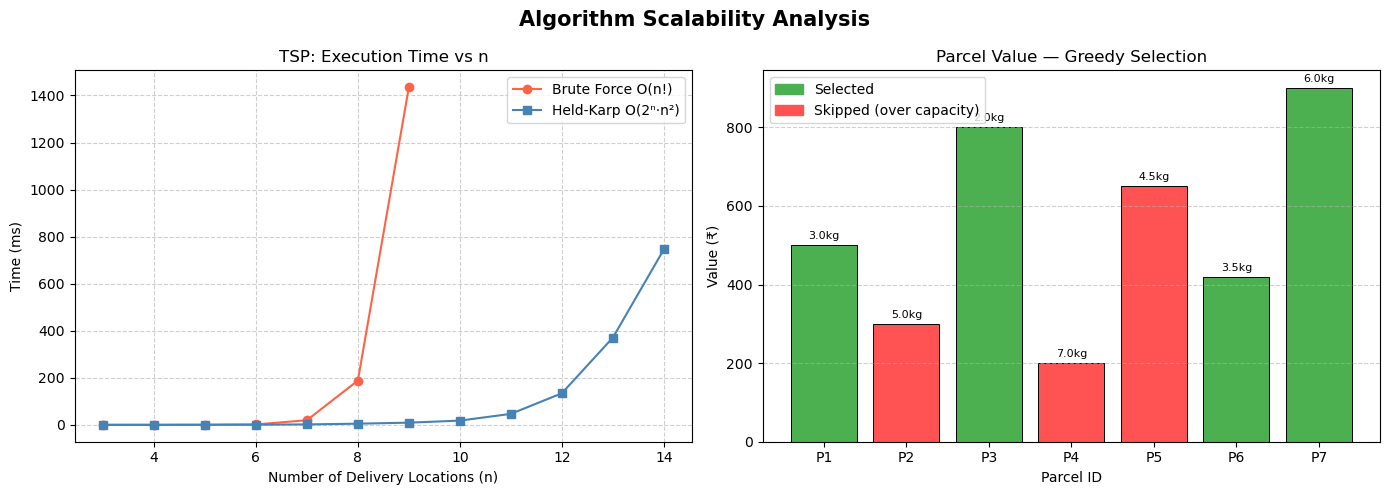

Plot saved to images/scalability_and_profit.png


In [14]:
# ── Scalability Profiling: Time vs Number of Locations ───────────────────────
# We test brute-force TSP and Held-Karp DP across increasing n values
# and measure execution time.

def random_dist_matrix(n: int, seed: int = 42) -> list[list[float]]:
    """Generate a random symmetric distance matrix of size n×n."""
    rng = random.Random(seed)
    mat = [[0]*n for _ in range(n)]
    for i in range(n):
        for j in range(i+1, n):
            d = rng.randint(5, 50)
            mat[i][j] = d
            mat[j][i] = d
    return mat


bf_sizes  = list(range(3, 10))   # brute-force: n=3..9 delivery nodes
hk_sizes  = list(range(3, 15))   # held-karp:   n=3..14

bf_times, hk_times = [], []

for n in bf_sizes:
    mat   = random_dist_matrix(n+1)
    nodes = list(range(1, n+1))
    t0    = time.perf_counter()
    tsp_brute_force(mat, nodes)
    bf_times.append((time.perf_counter() - t0) * 1000)

for n in hk_sizes:
    mat   = random_dist_matrix(n+1)
    nodes = list(range(0, n+1))
    t0    = time.perf_counter()
    tsp_held_karp(mat, nodes)
    hk_times.append((time.perf_counter() - t0) * 1000)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Algorithm Scalability Analysis", fontsize=15, fontweight="bold")

# --- Time vs n ---
ax = axes[0]
ax.plot(bf_sizes, bf_times, "o-", color="tomato",    label="Brute Force O(n!)")
ax.plot(hk_sizes, hk_times, "s-", color="steelblue", label="Held-Karp O(2ⁿ·n²)")
ax.set_xlabel("Number of Delivery Locations (n)")
ax.set_ylabel("Time (ms)")
ax.set_title("TSP: Execution Time vs n")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)

# --- Profit vs Weight (greedy selection) ---
ax2 = axes[1]
weights = [p["weight"] for p in PARCELS]
values  = [p["value"]  for p in PARCELS]
colors  = ["#4CAF50" if p in selected_greedy else "#FF5252" for p in PARCELS]
bars = ax2.bar([p["id"] for p in PARCELS], values, color=colors, edgecolor="black", linewidth=0.7)
ax2.set_xlabel("Parcel ID")
ax2.set_ylabel("Value (₹)")
ax2.set_title("Parcel Value — Greedy Selection")
selected_patch = mpatches.Patch(color="#4CAF50", label="Selected")
skipped_patch  = mpatches.Patch(color="#FF5252", label="Skipped (over capacity)")
ax2.legend(handles=[selected_patch, skipped_patch])
ax2.grid(axis="y", linestyle="--", alpha=0.6)
# Annotate with weight
for bar, p in zip(bars, PARCELS):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f"{p['weight']}kg", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("images/scalability_and_profit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to images/scalability_and_profit.png")

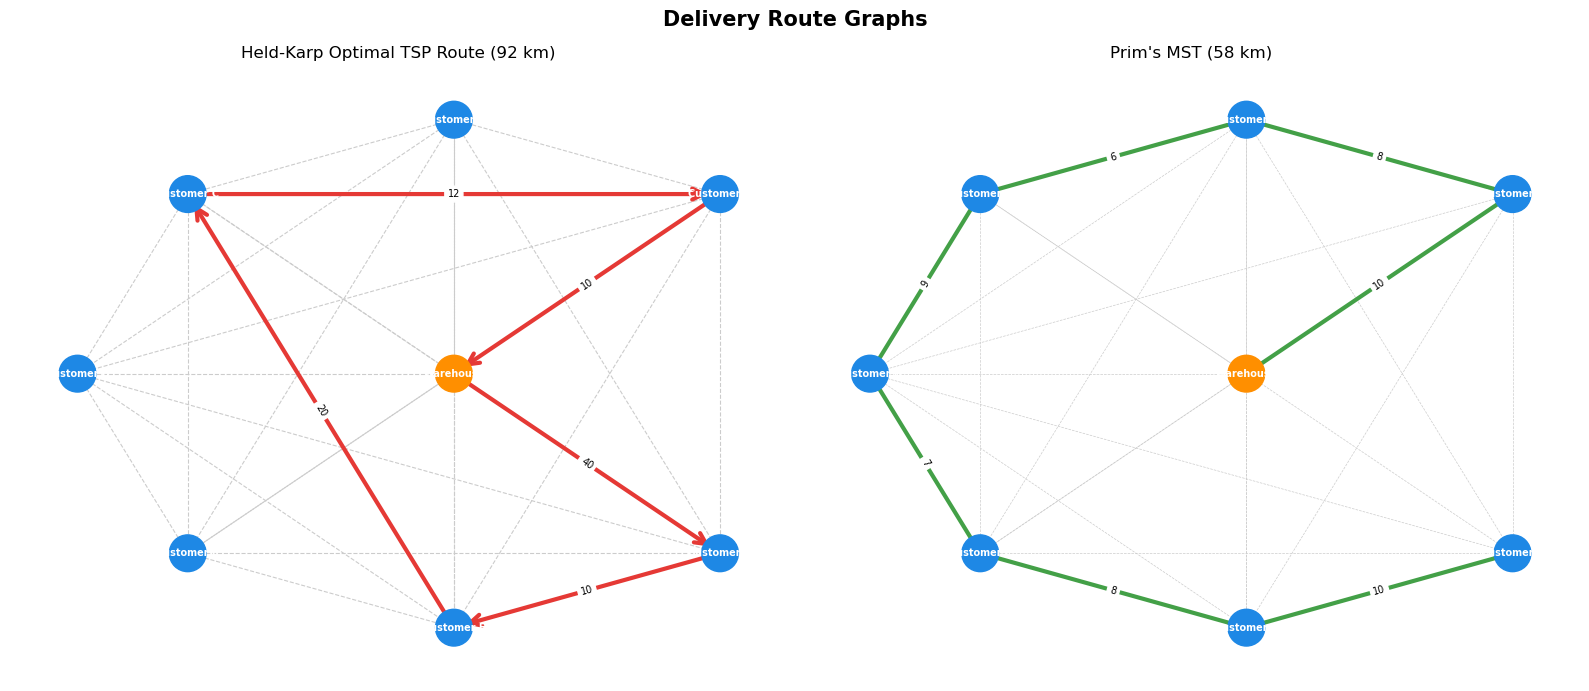

Route plot saved to images/route_graphs.png


In [15]:
# ── Route Visualization with NetworkX ────────────────────────────────────────
import os
os.makedirs("images", exist_ok=True)

# Build full graph
G = nx.Graph()
for i in range(NUM_LOCATIONS):
    G.add_node(i, label=LOCATION_NAMES[i])

for i in range(NUM_LOCATIONS):
    for j in range(i+1, NUM_LOCATIONS):
        if DIST_MATRIX[i][j] < INF:
            G.add_edge(i, j, weight=DIST_MATRIX[i][j])

# TSP optimal path edges
tsp_path_edges = list(zip(hk_path, hk_path[1:]))

# MST edges
mst_edge_set = {(u, v) for u, v, _ in mst_edges}

# Fixed positions (circular layout)
pos = nx.circular_layout(G)
pos[0] = np.array([0, 0])  # Warehouse at centre

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Delivery Route Graphs", fontsize=15, fontweight="bold")

# ---- Plot 1: TSP Optimal Route ----
ax1 = axes[0]
ax1.set_title(f"Held-Karp Optimal TSP Route ({hk_cost} km)", fontsize=12)

non_tsp_edges = [(u, v) for u, v in G.edges() if (u,v) not in tsp_path_edges
                                                and (v,u) not in tsp_path_edges]

nx.draw_networkx_edges(G, pos, edgelist=non_tsp_edges, ax=ax1,
                       edge_color="#cccccc", width=0.8, style="dashed")
nx.draw_networkx_edges(G, pos, edgelist=tsp_path_edges, ax=ax1,
                       edge_color="#E53935", width=3, arrows=True,
                       arrowstyle="->", arrowsize=20)

node_colors = ["#FF8F00" if n == 0 else "#1E88E5" for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, ax=ax1, node_color=node_colors, node_size=700)
nx.draw_networkx_labels(G, pos, labels=nx.get_node_attributes(G, "label"),
                        ax=ax1, font_size=7, font_color="white", font_weight="bold")
edge_labels = {(u, v): f"{DIST_MATRIX[u][v]}" for u, v in tsp_path_edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax1, font_size=7)
ax1.axis("off")

# ---- Plot 2: MST ----
ax2 = axes[1]
ax2.set_title(f"Prim's MST ({mst_cost} km)", fontsize=12)

mst_G = nx.Graph()
mst_G.add_nodes_from(G.nodes(data=True))
mst_G.add_edges_from([(u, v, {"weight": w}) for u, v, w in mst_edges])

nx.draw_networkx_edges(G, pos, edgelist=non_tsp_edges, ax=ax2,
                       edge_color="#cccccc", width=0.5, style="dashed")
nx.draw_networkx_edges(mst_G, pos, ax=ax2, edge_color="#43A047", width=3)
nx.draw_networkx_nodes(G, pos, ax=ax2, node_color=node_colors, node_size=700)
nx.draw_networkx_labels(G, pos, labels=nx.get_node_attributes(G, "label"),
                        ax=ax2, font_size=7, font_color="white", font_weight="bold")
mst_edge_label_dict = {(u, v): str(w) for u, v, w in mst_edges}
nx.draw_networkx_edge_labels(mst_G, pos, edge_labels=mst_edge_label_dict, ax=ax2, font_size=7)
ax2.axis("off")

plt.tight_layout()
plt.savefig("images/route_graphs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Route plot saved to images/route_graphs.png")

In [16]:
# ── Memory Profiling (optional) ───────────────────────────────────────────────
if MEMORY_PROFILER_AVAILABLE:
    nodes_for_mem = list(range(0, 12))
    mat_for_mem   = random_dist_matrix(12)

    mem_hk = memory_usage((tsp_held_karp, (mat_for_mem, nodes_for_mem)), max_usage=True)
    print(f"Held-Karp peak memory (n=11): {mem_hk:.2f} MiB")
else:
    print("Skipping memory profiling — memory_profiler not installed.")
    print("Install: pip install memory_profiler")

Held-Karp peak memory (n=11): 179.56 MiB


---
## Task 8 — Summary Table & Performance Comparison

In [18]:
# ── Algorithm Comparison Table ────────────────────────────────────────────────
print("Algorithm Performance Summary")
print("=" * 75)
header = f"{'Algorithm':<22} {'Strategy':<12} {'Complexity':<18} {'Result':<15} {'Optimal?'}"
print(header)
print("-" * 75)

rows = [
    ("Recursive Route Cost", "Recurrence",  "O(n!)",          "Route cost",         "Yes (small n)"),
    ("Greedy Parcel Select", "Greedy",      "O(n log n)",     f"₹{profit_greedy}",  "Approx"),
    ("DP Time Windows",      "Dynamic Prog","O(n²)",          f"{feasible_count} feasible", "Yes (given order)"),
    ("Dijkstra SSSP",        "Graph",       "O((V+E)log V)",  "Shortest paths",     "Yes"),
    ("Prim's MST",           "Graph",       "O(E log V)",     f"{mst_cost} km",     "Yes"),
    ("TSP Brute Force",      "Exhaustive",  "O(n!)",          f"{bf_cost} km",      "Yes"),
    ("TSP Held-Karp DP",     "DP",          "O(2ⁿ·n²)",       f"{hk_cost} km",      "Yes"),
]

for algo, strategy, complexity, result, optimal in rows:
    print(f"{algo:<22} {strategy:<12} {complexity:<18} {result:<15} {optimal}")

print("=" * 75)

Algorithm Performance Summary
Algorithm              Strategy     Complexity         Result          Optimal?
---------------------------------------------------------------------------
Recursive Route Cost   Recurrence   O(n!)              Route cost      Yes (small n)
Greedy Parcel Select   Greedy       O(n log n)         ₹2620.0         Approx
DP Time Windows        Dynamic Prog O(n²)              4 feasible      Yes (given order)
Dijkstra SSSP          Graph        O((V+E)log V)      Shortest paths  Yes
Prim's MST             Graph        O(E log V)         58 km           Yes
TSP Brute Force        Exhaustive   O(n!)              92 km           Yes
TSP Held-Karp DP       DP           O(2ⁿ·n²)           92 km           Yes


---
## Reflection & Discussion

### 1. Optimization vs Realism
The Held-Karp TSP gives the mathematically optimal route by total distance, but it does **not** account for real-world constraints like delivery time windows. The DP time-window check must be run separately to validate feasibility, and some TSP-optimal orderings may violate windows — requiring a hybrid approach.

### 2. Algorithm Trade-offs
| Algorithm | Speed | Scalability | Notes |
|-----------|-------|-------------|-------|
| Greedy Parcel Select | ⚡ Fastest | ✅ O(n log n) | Sub-optimal for 0/1 knapsack |
| DP Time Windows | ✅ Fast | ✅ O(n²) | Optimal order given sorted windows |
| Dijkstra | ✅ Fast | ✅ O(E log V) | Exact shortest paths |
| TSP Brute Force | ❌ Slow | ❌ O(n!) | Infeasible beyond n≈10 |
| TSP Held-Karp DP | ✅ Better | ⚠️ O(2ⁿn²) | Infeasible beyond n≈20 |

### 3. NP-hard Challenge
TSP brute force becomes infeasible around **n = 12** (12! ≈ 479 million permutations). Held-Karp handles up to **n ≈ 20** practically. Beyond that, heuristics (Nearest Neighbour, Christofides) or metaheuristics (GA, Simulated Annealing) are necessary.

### 4. Visualization Insight
Route graphs clearly showed that the MST and TSP routes are structurally similar for clustered nodes — confirming that the Christofides approximation (1.5× MST) would be an effective heuristic. The profit/weight chart quickly reveals which parcels offer the best value density.

### 5. Feature Suggestion
Adding **fuel cost** (proportional to weight × distance) and **multi-vehicle routing** (VRP) would significantly improve realism. A fleet of 3 vehicles with load balancing would reduce total delivery time and better model platforms like Amazon Prime.
